@author: Octavio Gutiérrez de Código Máquina

URL del canal: https://www.youtube.com/CodigoMaquina

URL del video: https://youtu.be/puC9emuHWqA

# Importancia por Permutación (Aprendizaje de Máquina Interpretable)
## Cargar y describir el conjunto de datos "Diabetes"



In [ ]:
from sklearn.datasets import load_diabetes

diabetes = load_diabetes(scaled=False)

print(diabetes["DESCR"])

.. _diabetes_dataset:

Diabetes dataset
----------------

Ten baseline variables, age, sex, body mass index, average blood
pressure, and six blood serum measurements were obtained for each of n =
442 diabetes patients, as well as the response of interest, a
quantitative measure of disease progression one year after baseline.

**Data Set Characteristics:**

:Number of Instances: 442

:Number of Attributes: First 10 columns are numeric predictive values

:Target: Column 11 is a quantitative measure of disease progression one year after baseline

:Attribute Information:
    - age     age in years
    - sex
    - bmi     body mass index
    - bp      average blood pressure
    - s1      tc, total serum cholesterol
    - s2      ldl, low-density lipoproteins
    - s3      hdl, high-density lipoproteins
    - s4      tch, total cholesterol / HDL
    - s5      ltg, possibly log of serum triglycerides level
    - s6      glu, blood sugar level

Note: Each of these 10 feature variables have bee

# Selección de variables independientes y variable objetivo

In [ ]:
# Nota: Variables y sus indíces
# 0:age, 1:sex, 2:bmi, 3:bp, 4:s1, 5:s2, 6:s3, 7:s4, 8:s5, 9:s6]

# Selección de variables ad-hoc para fines de explicación
nombre_variables = ["Edad", "Género", "IMC", "Presión arterial", "Colesterol"]
X = diabetes.data[:, [0, 1, 2, 3, 7]]

# Nivel de azúcar en sangre (s6)
y = diabetes.data[:, 9]

# Crea conjuntos de Entrenamiento y Prueba

In [ ]:
from sklearn.model_selection import train_test_split

X_entrena, X_prueba, y_entrena, y_prueba = \
            train_test_split(X, y, test_size=0.3, random_state=42)

# Preprocesar/Estandarizar los datos

In [ ]:
from sklearn.preprocessing import StandardScaler

X_entrena = StandardScaler().fit_transform(X_entrena)
y_entrena = StandardScaler().fit_transform(y_entrena.reshape(-1, 1))
X_prueba = StandardScaler().fit_transform(X_prueba)
y_prueba = StandardScaler().fit_transform(y_prueba.reshape(-1, 1))

# Define y entrena al Perceptrón Multicapa (MLP)

In [ ]:
from sklearn.neural_network import MLPRegressor

# Se creó un MLP con valores por defecto para fines de explicación
mlp = MLPRegressor(random_state=42, max_iter=1000)
mlp.fit(X_entrena, y_entrena)

/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:1650: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(


MLPRegressor(max_iter=1000, random_state=42)

# Importancia de Características por Permutación

---




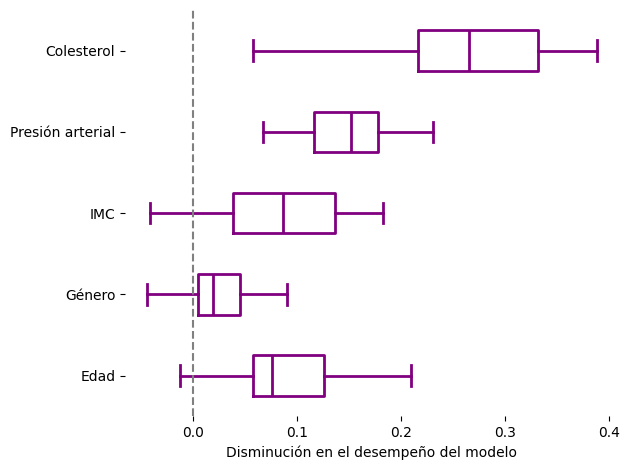

In [ ]:
from sklearn.inspection import permutation_importance
import matplotlib.pyplot as plt
import pandas as pd

# Calcula la Importancia de Características por Permutación
resultado = permutation_importance(mlp, X_prueba, y_prueba, \
                                   n_repeats=30, random_state=42)

# Crea un DataFrame para visualización de la importancia
importancias = pd.DataFrame(
    resultado.importances.T,
    columns = nombre_variables,
)

ax = importancias.plot.box(vert=False)

ax.set_xlabel("Disminución en el desempeño del modelo")
ax.figure.tight_layout()

# Detalles de la personalización de la visualización
for i, artist in enumerate(ax.artists):
    artist.set_edgecolor("purple")
    artist.set_linewidth(2)

for i, line in enumerate(ax.lines):
    line.set_color("purple")
    line.set_linewidth(2)

# Quitar marco
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_visible(False)
ax.spines["bottom"].set_visible(False)

# Incluir una línea en x = 0 para tener referencia de si mejoró o empeoró
ax.axvline(x=0, color="gray", linestyle="--")

plt.show()